In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("main_data1.csv")

In [4]:
df

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,movie_title,comb
0,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,Action Adventure Fantasy Sci-Fi,avatar,CCH Pounder Joel David Moore Wes Studi James C...
1,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,Action Adventure Fantasy,pirates of the caribbean: at world's end,Johnny Depp Orlando Bloom Jack Davenport Gore ...
2,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Action Adventure Thriller,spectre,Christoph Waltz Rory Kinnear Stephanie Sigman ...
3,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Action Thriller,the dark knight rises,Tom Hardy Christian Bale Joseph Gordon-Levitt ...
4,Doug Walker,Doug Walker,Rob Walker,unknown,Documentary,star wars: the force awakens,Doug Walker Rob Walker unknown Doug Walker Doc...
...,...,...,...,...,...,...,...
7501,Halina Reijn,Nicole Kidman,Harris Dickinson,Antonio Banderas,Thriller,babygirl,Nicole Kidman Harris Dickinson Antonio Bandera...
7502,Ben Smallbone,Neal McDonough,Dawn Olivieri,Currie Graham,Horror Thriller Western,homestead,Neal McDonough Dawn Olivieri Currie Graham Ben...
7503,Robert Eggers,Bill Skarsgård,Nicholas Hoult,Lily-Rose Depp,Drama Fantasy Horror,nosferatu,Bill Skarsgård Nicholas Hoult Lily-Rose Depp R...
7504,James Mangold,Timothée Chalamet,Edward Norton,Elle Fanning,Drama Music History,a complete unknown,Timothée Chalamet Edward Norton Elle Fanning J...


In [5]:
reshaped_df = pd.melt(df , id_vars=['movie_title'] , value_vars=['actor_1_name' , 'actor_2_name' , 'actor_3_name'] , var_name='actor_position' , value_name='actor_name')

In [6]:
reshaped_df

,movie_title,actor_position,actor_name
0,avatar,actor_1_name,CCH Pounder
1,pirates of the caribbean: at world's end,actor_1_name,Johnny Depp
2,spectre,actor_1_name,Christoph Waltz
3,the dark knight rises,actor_1_name,Tom Hardy
4,star wars: the force awakens,actor_1_name,Doug Walker
...,...,...,...
22513,babygirl,actor_3_name,Antonio Banderas
22514,homestead,actor_3_name,Currie Graham
22515,nosferatu,actor_3_name,Lily-Rose Depp
22516,a complete unknown,actor_3_name,Elle Fanning


In [7]:
reshaped_df = reshaped_df.drop(columns='actor_position')

In [8]:
reshaped_df

,movie_title,actor_name
0,avatar,CCH Pounder
1,pirates of the caribbean: at world's end,Johnny Depp
2,spectre,Christoph Waltz
3,the dark knight rises,Tom Hardy
4,star wars: the force awakens,Doug Walker
...,...,...
22513,babygirl,Antonio Banderas
22514,homestead,Currie Graham
22515,nosferatu,Lily-Rose Depp
22516,a complete unknown,Elle Fanning


In [10]:
reshaped_df.isnull().sum()

movie_title    0
actor_name     0
dtype: int64

In [11]:
reshaped_df.to_csv("actors.csv" , index=False)

In [12]:
reshaped_df

,movie_title,actor_name
0,avatar,CCH Pounder
1,pirates of the caribbean: at world's end,Johnny Depp
2,spectre,Christoph Waltz
3,the dark knight rises,Tom Hardy
4,star wars: the force awakens,Doug Walker
...,...,...
22513,babygirl,Antonio Banderas
22514,homestead,Currie Graham
22515,nosferatu,Lily-Rose Depp
22516,a complete unknown,Elle Fanning


In [15]:
reshaped_df.duplicated().sum()

50

In [16]:
reframed_df = reshaped_df.drop_duplicates()

In [17]:
reframed_df

,movie_title,actor_name
0,avatar,CCH Pounder
1,pirates of the caribbean: at world's end,Johnny Depp
2,spectre,Christoph Waltz
3,the dark knight rises,Tom Hardy
4,star wars: the force awakens,Doug Walker
...,...,...
22513,babygirl,Antonio Banderas
22514,homestead,Currie Graham
22515,nosferatu,Lily-Rose Depp
22516,a complete unknown,Elle Fanning


In [18]:
# reframed_df.to_csv("actors1.csv" , index=False)

In [2]:
pip install networkx


   ---------------------------------------- 1.9/1.9 MB 766.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


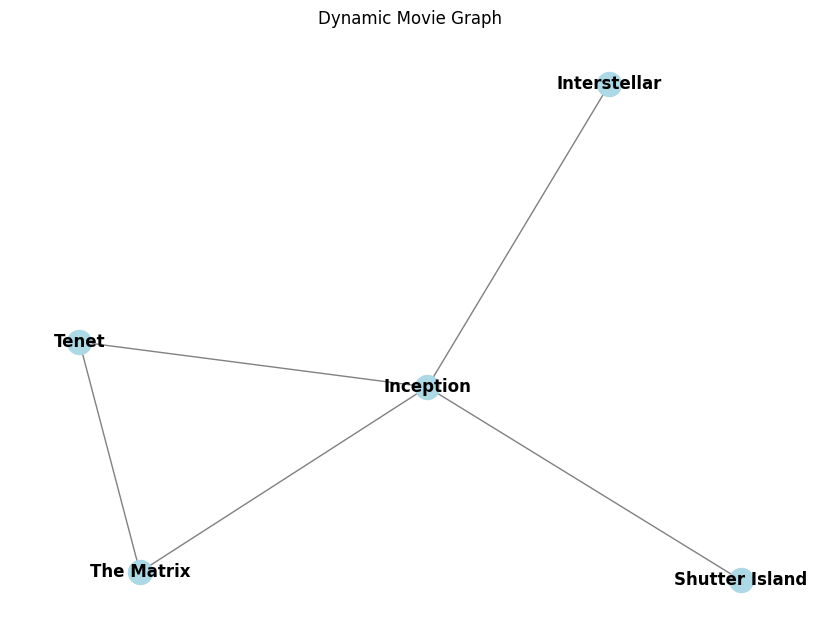

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.Graph()

# Add movies as nodes
movies = ["Inception", "Interstellar", "Tenet", "The Matrix", "Shutter Island"]
for movie in movies:
    G.add_node(movie)

# Add connections (edges) based on similarities
G.add_edges_from([
    ("Inception", "Interstellar"),  # Same director (Christopher Nolan)
    ("Inception", "Tenet"),  # Same director
    ("The Matrix", "Inception"),  # Similar theme (dream/reality)
    ("Shutter Island", "Inception"),  # Mind-bending twist endings
    ("The Matrix", "Tenet")  # Sci-fi with time manipulation
])

# Draw the graph
plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True, node_color="lightblue", edge_color="gray", font_size=12, font_weight="bold")
plt.title("Dynamic Movie Graph")
plt.show()
